# Implementing Task I

1) implement a simple quantum operation with Cirq or Pennylane <br>
a) With 5 qubits <br>
b) Apply Hadamard operation on every qubit <br>
c) Apply CNOT operation on (0, 1), (1,2), (2,3), (3,4) <br>
d) SWAP (0, 4) <br>
e) Rotate X with pi/2 on any qubit <br>
f) Plot the circuit <br>


(<Figure size 1000x600 with 1 Axes>, <Axes: >)

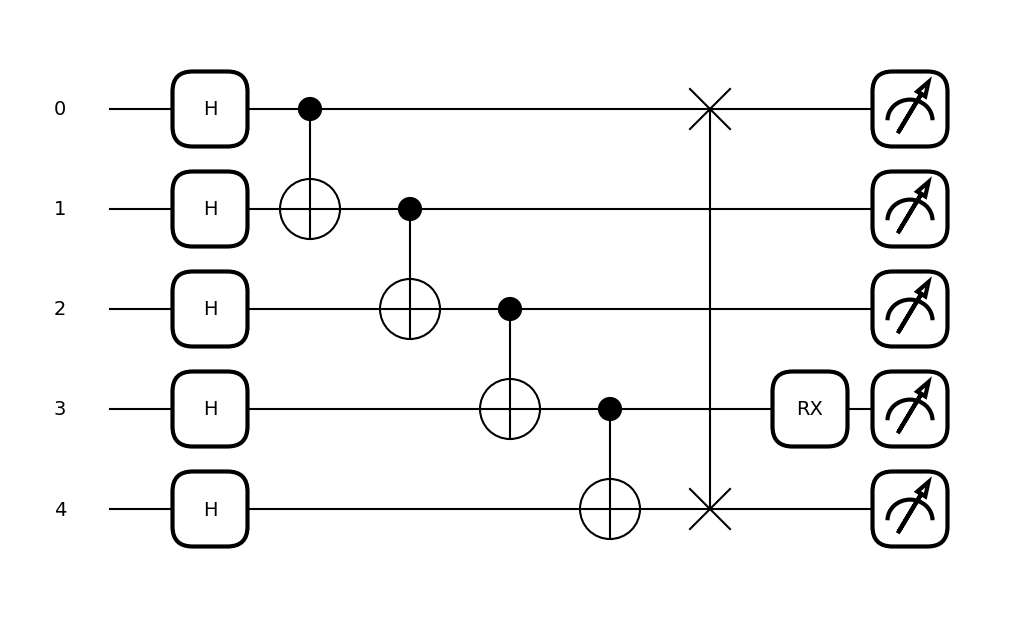

In [1]:
import pennylane as qml
import numpy as np

dev = qml.device("default.qubit", wires=5)
@qml.qnode(dev)
def circuit():
    for i in range(len(dev.wires)):
        qml.Hadamard(wires=i)
    for i in range(len(dev.wires) - 1):
        qml.CNOT(wires=[i, i + 1])
    qml.SWAP(wires=[0,4])
    qml.RX(np.pi/2, wires=3)
    return qml.state()

qml.draw_mpl(circuit)()

2) Implement a second circuit with a framework of your choice: <br>
a) Apply a Hadmard gate to the first qubit<br>
b) rotate the second qubit by pi/3 around X<br>
c) Apply Hadamard gate to the third and fourth qubit<br>
d) Perform a swap test between the states of the first and second qubit |q1 q2> and the third and fourth qubit |q3 q4><br>


In [8]:
dev = qml.device("default.qubit", wires=5)

def swap_test(q1, q2, q3, q4, ancilla):
    qml.Hadamard(wires=ancilla)
    qml.CSWAP(wires=[ancilla, q1, q3])
    qml.CSWAP(wires=[ancilla, q2, q4])
    qml.Hadamard(wires=ancilla)

@qml.qnode(dev)
def circuit2():
    qml.Hadamard(wires=0)
    qml.RX(np.pi/3, wires=1)
    for i in range(2, 4):
        qml.Hadamard(wires=i)
    swap_test(0, 1, 2, 3, 4)
    return qml.probs(wires=4)

print(circuit2())

[0.75 0.25]
